# Team position through time
This notebook studies the team's position through different seasons. It uses the `standings` table that we created.

In [14]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(str(Path.cwd().parent))

In [15]:
sys.path

['C:\\Users\\fadik\\AppData\\Local\\Programs\\Python\\Python314\\python314.zip',
 'C:\\Users\\fadik\\AppData\\Local\\Programs\\Python\\Python314\\DLLs',
 'C:\\Users\\fadik\\AppData\\Local\\Programs\\Python\\Python314\\Lib',
 'C:\\Users\\fadik\\AppData\\Local\\Programs\\Python\\Python314',
 'c:\\Users\\fadik\\Desktop\\Career Recovery Plan\\odds-vs-reality\\vs_env',
 '',
 'c:\\Users\\fadik\\Desktop\\Career Recovery Plan\\odds-vs-reality\\vs_env\\Lib\\site-packages',
 WindowsPath('c:/Users/fadik/Desktop/Career Recovery Plan/odds-vs-reality'),
 'c:\\Users\\fadik\\Desktop\\Career Recovery Plan\\odds-vs-reality']

In [16]:
from src.db.engine import engine

In [17]:
standings_df = pd.read_sql(
    """SELECT * from standings;
    """,
    engine
)

In [18]:
standings_df

,league_division,season,position,team,played,wins,draws,losses,goals_for,goals_against,goal_diff,points
0,L1,21/22,1,Paris SG,38,26,8,4,90,36,54,86
1,L1,21/22,2,Marseille,38,21,8,9,63,38,25,71
2,L1,21/22,3,Monaco,38,20,9,9,65,40,25,69
3,L1,21/22,4,Nice,38,20,7,11,52,36,16,67
4,L1,21/22,5,Rennes,38,20,6,12,82,40,42,66
...,...,...,...,...,...,...,...,...,...,...,...,...
89,L1,25/26,14,Le Havre,34,7,14,13,32,44,-12,35
90,L1,25/26,15,Auxerre,34,8,10,16,34,44,-10,34
91,L1,25/26,16,Nice,34,7,11,16,37,60,-23,32
92,L1,25/26,17,Nantes,33,5,8,20,29,52,-23,23


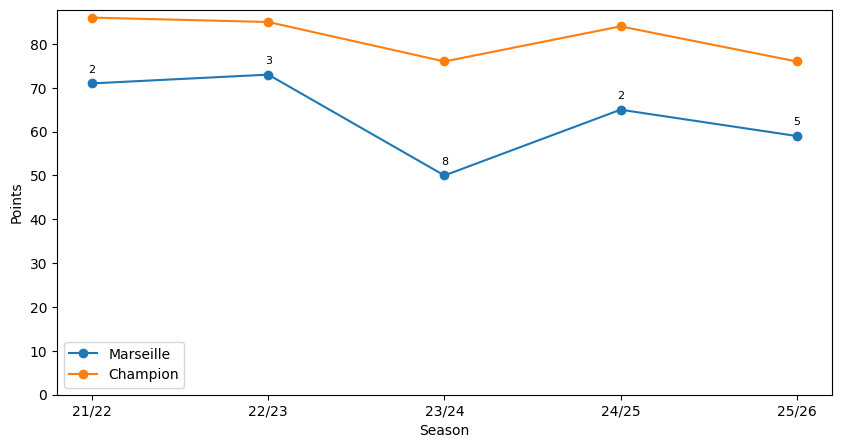

In [38]:
marseille_pts = standings_df.loc[
    standings_df['team'] == 'Marseille',
    ['season', 'points', 'position']
].set_index('season').sort_index()

winner_pts = standings_df.loc[
    standings_df['position'] == 1,
    ['season' , 'points', 'position']
].set_index('season').sort_index()

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    marseille_pts.index,
    marseille_pts["points"],
    marker="o",
    label="Marseille"
)

ax.plot(
    winner_pts.index,
    winner_pts["points"],
    marker="o",
    label="Champion"
)

for season, row in marseille_pts.iterrows():
    ax.annotate(
        int(row["position"]),
        (season, row["points"]),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=8
    )

ax.set_ylabel("Points")
ax.set_ylim(bottom=0)
ax.set_xlabel("Season")
ax.legend()

plt.show()